# Lab 16 — Sampling, Quantization and Digital Telephony

**Companion to Chapter 5** (*Sampling, Quantization and Digital Telephony*).
**Time needed:** about 75 minutes. **Difficulty:** introductory to core.

Every digital system starts by turning a waveform into numbers: sample it in time, quantize it in
amplitude. Telephony did this first and did it brilliantly: 8000 samples per second, 8 bits per sample,
logarithmic companding so a whisper and a shout get the same relative accuracy, and 24 such channels
woven into a 1.544 Mb/s T1 line. This lab rebuilds that whole chain and then the modern way to convert:
oversample with a crude 1-bit quantizer and shape the noise out of band (sigma-delta).

### What you will learn
1. Predict aliasing, and the droop of zero-order-hold reconstruction.
2. Measure SQNR versus bits and versus signal level; see what dither does.
3. Implement μ-law and A-law companding (ITU-T G.711) and measure their dynamic range.
4. Explore delta modulation (slope overload versus granular noise) and sigma-delta noise shaping versus OSR and order.
5. Build a T1 frame and a D4 superframe.

### Prerequisites
Lab 1 (complex sampling). The sampling theorem (Chapter 2). Chapter 5.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | Sampling and aliasing | yes |
| 2 | Reconstruction and the zero-order hold | |
| 3 | Uniform quantization: SQNR vs bits and level | |
| 4 | Dither | |
| 5 | μ-law and A-law companding | |
| 6 | Delta modulation | yes |
| 7 | Sigma-delta: oversampling and noise shaping | |
| 8 | T1 framing | |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, butter, sosfiltfilt
import commlib as cl
from commlib import labkit as lk

rng = lk.setup(seed=16, lab="16")

def sqnr_db(x, xq):
    return lk.db(np.mean(x ** 2) / np.mean((xq - x) ** 2))

Lab 16 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 16


## 1. Sampling and aliasing

Sampling a real signal at $f_s$ makes its spectrum periodic with period $f_s$; a tone at $f$ appears at
$|f - k f_s|$ for the nearest integer $k$, i.e. it **folds** about multiples of $f_s/2$. Above $f_s/2$ the
samples of two different tones are *identical*: no processing after the sampler can tell them apart, so the
anti-alias filter must come first. Telephony samples at 8 kHz after filtering to about 3.4 kHz.

### Interactive: a tone and its samples

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

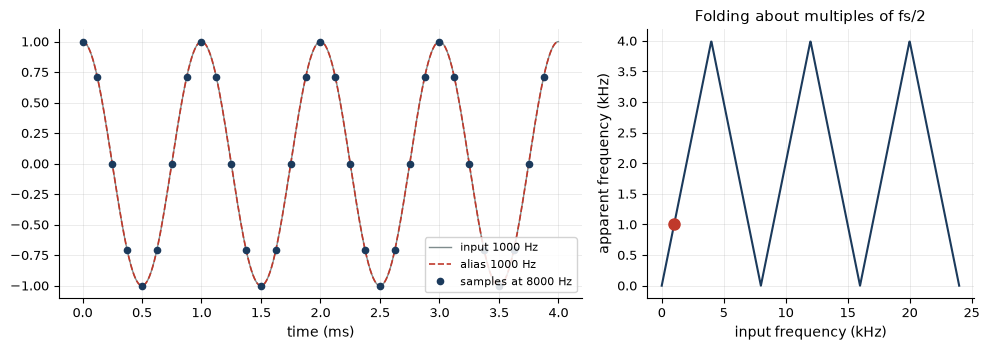

In [3]:
def alias_demo(f_tone=1000.0, fs=8000.0):
    tc = np.linspace(0, 0.004, 4000)
    ts = np.arange(0, 0.004, 1 / fs)
    fa = abs(f_tone - fs * round(f_tone / fs))
    f, ax = lk.fig("row2", 1, 2, gridspec_kw={"width_ratios": [1.6, 1]})
    ax[0].plot(tc * 1e3, np.cos(2 * np.pi * f_tone * tc), color=lk.GRAY, lw=1, label=f"input {f_tone:.0f} Hz")
    ax[0].plot(tc * 1e3, np.cos(2 * np.pi * fa * tc), color=lk.RED, lw=1.2, ls="--", label=f"alias {fa:.0f} Hz")
    ax[0].plot(ts * 1e3, np.cos(2 * np.pi * f_tone * ts), "o", color=lk.NAVY, label=f"samples at {fs:.0f} Hz")
    ax[0].set_xlabel("time (ms)"); ax[0].legend(fontsize=8, loc="lower right")
    fin = np.linspace(0, 3 * fs, 1000)
    ax[1].plot(fin / 1e3, np.abs(fin - fs * np.round(fin / fs)) / 1e3, color=lk.NAVY)
    ax[1].plot(f_tone / 1e3, fa / 1e3, "o", color=lk.RED, ms=8)
    ax[1].set_xlabel("input frequency (kHz)"); ax[1].set_ylabel("apparent frequency (kHz)")
    ax[1].set_title("Folding about multiples of fs/2")
    lk.show(f)

lk.interact(alias_demo, f_tone=lk.slider(1000, 0, 24000, 50, "tone (Hz)"), fs=lk.slider(8000, 2000, 16000, 500, "fs (Hz)"))

**What you should see.** Below 4 kHz the red alias coincides with the input. Move the tone to 7 kHz: the
samples (dots) are exactly those of a 1 kHz tone. The folding diagram on the right is a triangle wave.

### Try it yourself 1.1
A 10.3 kHz tone is sampled at 8 kHz without an anti-alias filter. At what frequency (Hz) does it appear?

In [5]:
answer_1_1 = None
lk.check("1.1 alias of 10.3 kHz at fs = 8 kHz", answer_1_1, abs(10300 - 8000 * round(10300 / 8000)), atol=1)

[TODO] 1.1 alias of 10.3 kHz at fs = 8 kHz: not attempted yet: replace the None with your answer

## 2. Reconstruction and the zero-order hold

Ideal reconstruction interpolates the samples with sinc pulses. A real DAC holds each value for one sample
period (**zero-order hold**), whose frequency response $\mathrm{sinc}(f/f_s)$ droops by
$20\log_{10}(\pi/2) = 3.92$ dB at $f_s/2$ and leaves images around every multiple of $f_s$; a smoothing filter
(and often an inverse-sinc correction) follows.

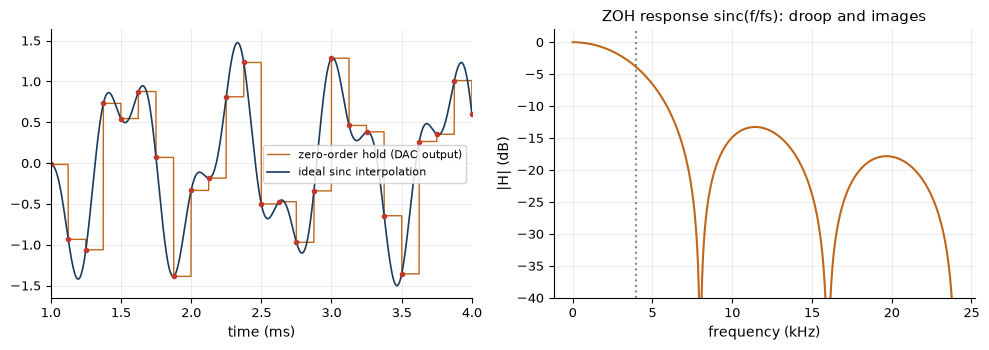

In [7]:
fs0 = 8000
n = np.arange(40)
xs = np.cos(2 * np.pi * 1300 * n / fs0) + 0.5 * np.sin(2 * np.pi * 3100 * n / fs0)
tt = np.linspace(0, 39 / fs0, 4000)
sinc_rec = np.sum(xs[None, :] * np.sinc(tt[:, None] * fs0 - n[None, :]), axis=1)
zoh = xs[np.minimum((tt * fs0).astype(int), 39)]
f, ax = lk.fig("row2", 1, 2)
ax[0].plot(tt * 1e3, zoh, color=lk.ORANGE, lw=1, label="zero-order hold (DAC output)")
ax[0].plot(tt * 1e3, sinc_rec, color=lk.NAVY, lw=1.2, label="ideal sinc interpolation")
ax[0].plot(n / fs0 * 1e3, xs, "o", color=lk.RED, ms=3); ax[0].set_xlim(1, 4); ax[0].legend(fontsize=8)
ax[0].set_xlabel("time (ms)")
fr = np.linspace(0, 3 * fs0, 1000)
ax[1].plot(fr / 1e3, lk.db(np.sinc(fr / fs0) ** 2), color=lk.ORANGE)
ax[1].axvline(fs0 / 2e3, color=lk.GRAY, ls=":"); ax[1].set_ylim(-40, 2)
ax[1].set_xlabel("frequency (kHz)"); ax[1].set_ylabel("|H| (dB)"); ax[1].set_title("ZOH response sinc(f/fs): droop and images")
lk.show(f)

### Try it yourself 2.1
How many dB does a zero-order hold attenuate a 3.4 kHz tone when $f_s$ = 8 kHz?

In [9]:
answer_2_1 = None
lk.check("2.1 ZOH droop at 3.4 kHz, fs = 8 kHz (dB)", answer_2_1, -lk.db(np.sinc(3400 / 8000) ** 2), atol=0.05)

[TODO] 2.1 ZOH droop at 3.4 kHz, fs = 8 kHz (dB): not attempted yet: replace the None with your answer

## 3. Uniform quantization: SQNR versus bits and level

A $b$-bit uniform quantizer over $[-1, 1)$ has step $\Delta = 2^{1-b}$. If the signal is busy enough, the error
is uniform on $[-\Delta/2, \Delta/2)$ with power $\Delta^2/12$, giving for a full-scale sine
$\mathrm{SQNR} = 6.02b + 1.76$ dB. Two practical corrections: a Gaussian-like signal (speech) must be scaled
down to avoid clipping (a **loading factor** of about 4σ costs ~7 dB), and below full scale the SQNR falls
**1 dB per dB**. That last fact is what companding fixes.

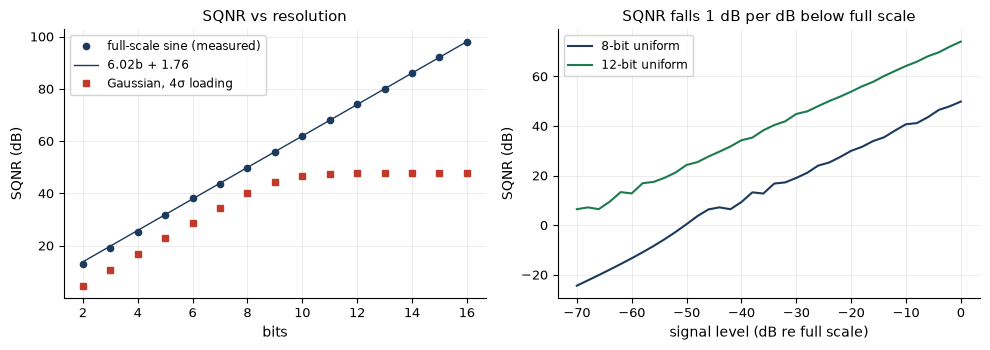

In [11]:
def quantize(x, bits):
    d = 2.0 ** (1 - bits)
    return np.clip(d * (np.floor(x / d) + 0.5), -1 + d / 2, 1 - d / 2)

N = 1 << 16
sine = np.sin(2 * np.pi * 0.01234567 * np.arange(N))
gauss = rng.standard_normal(N) / 4                 # 4-sigma loading
bits_ = np.arange(2, 17)
f, ax = lk.fig("row2", 1, 2)
ax[0].plot(bits_, [sqnr_db(sine, quantize(sine, b)) for b in bits_], "o", label="full-scale sine (measured)")
ax[0].plot(bits_, 6.02 * bits_ + 1.76, color=lk.NAVY, lw=1, label="6.02b + 1.76")
ax[0].plot(bits_, [sqnr_db(gauss, quantize(gauss, b)) for b in bits_], "s", color=lk.RED, label="Gaussian, 4σ loading")
ax[0].set_xlabel("bits"); ax[0].set_ylabel("SQNR (dB)"); ax[0].legend(); ax[0].set_title("SQNR vs resolution")
levels = np.arange(-70, 1, 2.0)
ax[1].plot(levels, [sqnr_db(10 ** (l_ / 20) * sine, quantize(10 ** (l_ / 20) * sine, 8)) for l_ in levels], color=lk.NAVY,
           label="8-bit uniform")
ax[1].plot(levels, [sqnr_db(10 ** (l_ / 20) * sine, quantize(10 ** (l_ / 20) * sine, 12)) for l_ in levels], color=lk.GREEN,
           label="12-bit uniform")
ax[1].set_xlabel("signal level (dB re full scale)"); ax[1].set_ylabel("SQNR (dB)"); ax[1].legend()
ax[1].set_title("SQNR falls 1 dB per dB below full scale")
lk.show(f)

**What you should see.** The sine sits on the 6 dB/bit line; the Gaussian signal is about 7 dB lower, and above
about 10 bits it stops improving at ~47 dB: the rare peaks beyond 4σ are clipped, and this **overload noise**
no longer depends on the step size. Choosing the loading factor balances granular against overload noise. On the
right, each curve is a 45° line: a quiet talker 40 dB below full scale gets only about 10 dB SQNR from 8 uniform bits.

## 4. Dither

For low-level, periodic signals the quantization error is *not* noise: it is a deterministic function of the
signal, so it shows up as **harmonics** (audible distortion). Adding a small random **dither** before the
quantizer (here triangular-pdf, ±1 LSB) decorrelates the error from the signal: the harmonics turn into a
slightly higher but benign white noise floor. Every audio ADC and image sensor relies on this.

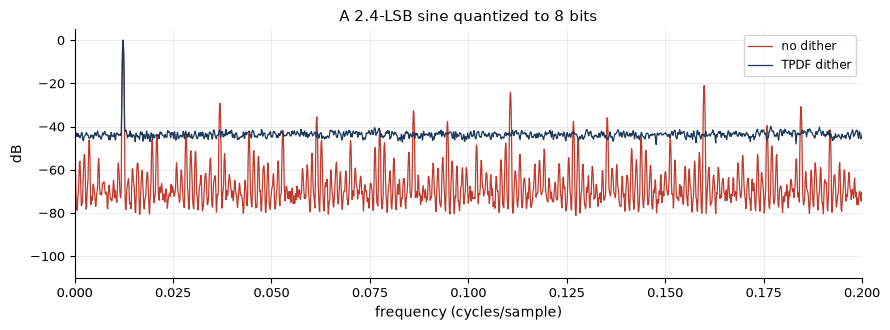

In [14]:
x4 = 0.6 * 2 ** (1 - 8) * np.sin(2 * np.pi * 0.0123 * np.arange(N)) * 4      # about 2.4 LSB peak
d_tpdf = (rng.random(N) - rng.random(N)) * 2 ** (1 - 8)
f, ax = lk.fig("wide")
for sig, lab, col in [(quantize(x4, 8), "no dither", lk.RED), (quantize(x4 + d_tpdf, 8), "TPDF dither", lk.NAVY)]:
    fr, p = welch(sig, nperseg=8192, window="blackmanharris")
    ax.plot(fr, lk.db(p / p.max()), color=col, lw=0.9, label=lab)
ax.set_xlim(0, 0.2); ax.set_ylim(-110, 5); ax.set_xlabel("frequency (cycles/sample)"); ax.set_ylabel("dB")
ax.legend(); ax.set_title("A 2.4-LSB sine quantized to 8 bits")
lk.show(f)

**What you should see.** Without dither, a comb of odd harmonics of the 0.0123 tone; with dither, a clean tone
on a flat noise floor.

## 5. μ-law and A-law companding (ITU-T G.711)

Companding compresses the signal logarithmically before a uniform quantizer and expands it afterwards, so the
step size grows with the amplitude and the *relative* error stays roughly constant:

$$c_\mu(x) = \mathrm{sgn}(x)\frac{\ln(1+\mu|x|)}{\ln(1+\mu)},\ \mu = 255\ \text{(North America, Japan)};\qquad
c_A(x) = \mathrm{sgn}(x)\begin{cases}\frac{A|x|}{1+\ln A} & |x| < 1/A\\ \frac{1+\ln(A|x|)}{1+\ln A} & \text{else}\end{cases},\ A = 87.6\ \text{(Europe)}.$$

G.711 implements both as 8-bit segmented (piecewise-linear) approximations; we use the smooth curves.

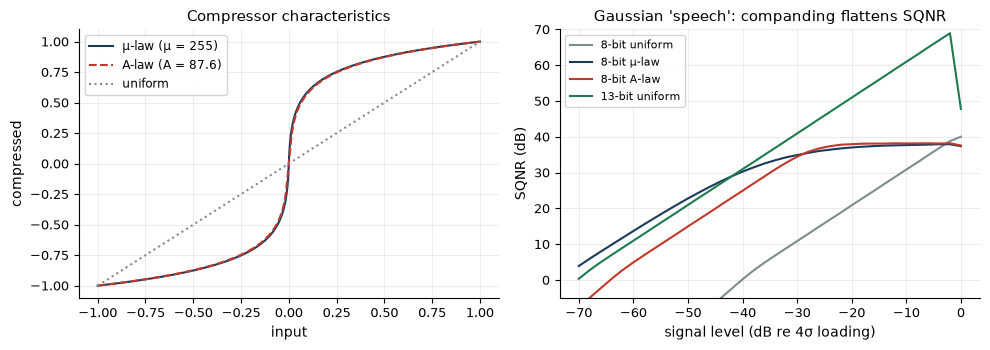

In [17]:
mu, A = 255.0, 87.6
c_mu = lambda x: np.sign(x) * np.log1p(mu * np.abs(x)) / np.log1p(mu)
e_mu = lambda y: np.sign(y) * np.expm1(np.abs(y) * np.log1p(mu)) / mu
def c_A(x):
    a = np.abs(x)
    return np.sign(x) * np.where(a < 1 / A, A * a, 1 + np.log(np.maximum(A * a, 1e-12))) / (1 + np.log(A))
def e_A(y):
    a = np.abs(y) * (1 + np.log(A))
    return np.sign(y) * np.where(a < 1, a / A, np.exp(a - 1) / A)

f, ax = lk.fig("row2", 1, 2)
xx = np.linspace(-1, 1, 1001)
ax[0].plot(xx, c_mu(xx), label="μ-law (μ = 255)"); ax[0].plot(xx, c_A(xx), "--", label="A-law (A = 87.6)")
ax[0].plot(xx, xx, ":", color=lk.GRAY, label="uniform"); ax[0].legend(); ax[0].set_title("Compressor characteristics")
ax[0].set_xlabel("input"); ax[0].set_ylabel("compressed")
for name, fn, col in [("8-bit uniform", lambda s: quantize(s, 8), lk.GRAY),
                      ("8-bit μ-law", lambda s: e_mu(quantize(c_mu(s), 8)), lk.NAVY),
                      ("8-bit A-law", lambda s: e_A(quantize(c_A(s), 8)), lk.RED),
                      ("13-bit uniform", lambda s: quantize(s, 13), lk.GREEN)]:
    ax[1].plot(levels, [sqnr_db(10 ** (l_ / 20) * gauss, fn(10 ** (l_ / 20) * gauss)) for l_ in levels], color=col, label=name)
ax[1].set_xlabel("signal level (dB re 4σ loading)"); ax[1].set_ylabel("SQNR (dB)"); ax[1].legend(fontsize=8)
ax[1].set_title("Gaussian 'speech': companding flattens SQNR"); ax[1].set_ylim(-5, 70)
lk.show(f)

**What you should see.** μ-law and A-law hold an SQNR of about 30–38 dB over a 40 dB range of talker levels,
where 8-bit uniform falls off immediately; 8-bit companded PCM matches the low-level performance of about
13-bit uniform PCM, with a few dB less at full scale. That 5-bit saving made 64 kb/s telephony possible.

### Try it yourself 5.1
What is the μ-law (μ = 255) compressed value of $x = 0.1$?

In [19]:
answer_5_1 = None
lk.check("5.1 μ-law compressed value of 0.1", answer_5_1, float(c_mu(0.1)), atol=0.002)

[TODO] 5.1 μ-law compressed value of 0.1: not attempted yet: replace the None with your answer

## 6. Delta modulation

Delta modulation sends **one bit per sample**: is the input above or below the running staircase
approximation? The staircase moves by a fixed step $\delta$. Too small a step and the staircase cannot keep
up with steep signals (**slope overload**, when $|dx/dt| > \delta f_s$); too large and it chatters around flat
portions (**granular noise**). Adaptive versions (CVSD, used in military radios and Bluetooth voice) change the step on the fly.

### Interactive

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

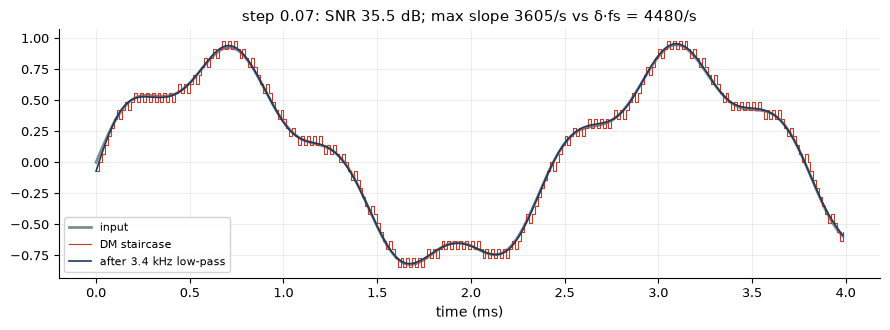

In [21]:
fsd = 64_000
td = np.arange(int(0.004 * fsd)) / fsd
xd = 0.8 * np.sin(2 * np.pi * 400 * td) + 0.15 * np.sin(2 * np.pi * 1700 * td)

def delta_demo(step=0.05):
    est = np.empty_like(xd); acc = 0.0
    for i, v in enumerate(xd):
        acc += step if v > acc else -step
        est[i] = acc
    rec = sosfiltfilt(butter(4, 3400, fs=fsd, output="sos"), est)
    f, ax = lk.fig("wide")
    ax.plot(td * 1e3, xd, color=lk.GRAY, lw=2, label="input")
    ax.step(td * 1e3, est, where="post", color=lk.RED, lw=0.8, label="DM staircase")
    ax.plot(td * 1e3, rec, color=lk.NAVY, lw=1.2, label="after 3.4 kHz low-pass")
    slope_max = np.max(np.abs(np.diff(xd))) * fsd
    ax.set_title(f"step {step}: SNR {sqnr_db(xd, rec):.1f} dB; max slope {slope_max:.0f}/s vs δ·fs = {step * fsd:.0f}/s")
    ax.set_xlabel("time (ms)"); ax.legend(fontsize=8)
    lk.show(f)

lk.interact(delta_demo, step=lk.slider(0.07, 0.005, 0.2, 0.005, "step δ"))

**What you should see.** With δ = 0.07, $\delta f_s$ exceeds the signal's maximum slope and the staircase tracks
well. At δ = 0.03 it falls behind on the steep slopes (slope overload); at δ = 0.15 it chatters (granular noise).

## 7. Sigma-delta: oversampling and noise shaping

A sigma-delta modulator puts the 1-bit quantizer inside a feedback loop with an integrator. The output follows
the input on average, and the quantization noise is pushed (shaped) toward high frequencies by the
noise-transfer function $(1 - z^{-1})^L$ for an $L$-th order loop. A digital decimation filter then removes the
out-of-band noise. The in-band SQNR grows by about $(6L + 3)$ dB per doubling of the **oversampling ratio**
(OSR): 9 dB/octave for first order, 15 for second order. This is how almost every audio ADC/DAC and many
RF ADCs achieve 16–24 bits from a 1-bit comparator.

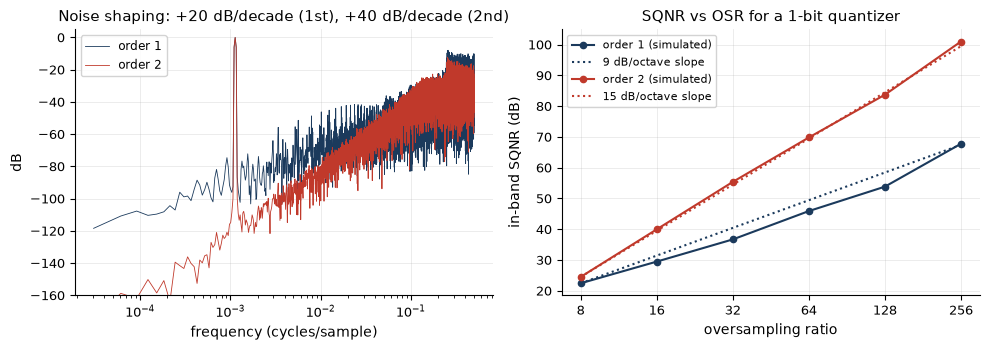

In [24]:
def sigma_delta(x, order):
    y = np.empty_like(x); i1 = i2 = 0.0; v = 0.0
    for n_, xn in enumerate(x):
        if order == 1:
            i1 += xn - v
            v = 1.0 if i1 >= 0 else -1.0
        else:                                          # CIFB second-order loop (Boser-Wooley style)
            i1 += xn - v
            i2 += i1 - v
            v = 1.0 if i2 >= 0 else -1.0
        y[n_] = v
    return y

Nsd = 1 << 15
k0 = 37                                               # tone in FFT bin 37 -> coherent sampling
xsd = 0.5 * np.sin(2 * np.pi * k0 * np.arange(Nsd) / Nsd)
f, ax = lk.fig("row2", 1, 2)
res = {}
win = np.hanning(Nsd)
for order, col in [(1, lk.NAVY), (2, lk.RED)]:
    y = sigma_delta(xsd, order)
    Y = np.abs(np.fft.rfft(y * win)) ** 2
    fr = np.fft.rfftfreq(Nsd)
    ax[0].semilogx(fr[1:], lk.db(Y[1:] / Y.max()), color=col, lw=0.6, label=f"order {order}")
    sig_bins = np.zeros(len(Y), bool); sig_bins[k0 - 3:k0 + 4] = True
    osrs = 2 ** np.arange(3, 9)
    res[order] = [lk.db(Y[sig_bins].sum() / Y[(fr < 0.5 / o) & ~sig_bins & (np.arange(len(Y)) > 2)].sum()) for o in osrs]
ax[0].set_xlabel("frequency (cycles/sample)"); ax[0].set_ylabel("dB"); ax[0].legend(); ax[0].set_ylim(-160, 5)
ax[0].set_title("Noise shaping: +20 dB/decade (1st), +40 dB/decade (2nd)")
for order, col in [(1, lk.NAVY), (2, lk.RED)]:
    ax[1].plot(np.log2(osrs), res[order], "o-", color=col, label=f"order {order} (simulated)")
    ax[1].plot(np.log2(osrs), res[order][0] + (6 * order + 3) * (np.log2(osrs) - 3), ":", color=col,
               label=f"{6 * order + 3} dB/octave slope")
ax[1].set_xticks(np.log2(osrs), [str(o) for o in osrs]); ax[1].set_xlabel("oversampling ratio")
ax[1].set_ylabel("in-band SQNR (dB)"); ax[1].legend(fontsize=8); ax[1].set_title("SQNR vs OSR for a 1-bit quantizer")
lk.show(f)

**What you should see.** The 1-bit output's noise rises with frequency, steeper for second order. In band, the
SQNR climbs about 9 dB (first order) and 15 dB (second order) per doubling of the OSR; at OSR 256 the second-order
loop exceeds 90 dB, i.e. about 15 effective bits from a single comparator. (First-order loops also produce idle
tones for some inputs, which is why practical converters use higher order and dither.)

## 8. T1 framing

A DS1/T1 frame carries one 8-bit sample from each of 24 voice channels plus one framing bit: 193 bits every
125 µs, i.e. $193 \times 8000 = 1.544$ Mb/s. Twelve frames form a **D4 superframe**: the framing bits spell the
pattern 100011011100 (alternating terminal-framing and signalling-framing bits), and in frames 6 and 12 the
least significant bit of every channel is "robbed" for on-hook/off-hook signalling (bits A and B), which is why
T1 voice channels are only 56 kb/s clean for data. The European E1 instead uses 32 timeslots of 8 bits
(2.048 Mb/s), with timeslot 0 for framing and timeslot 16 for signalling.

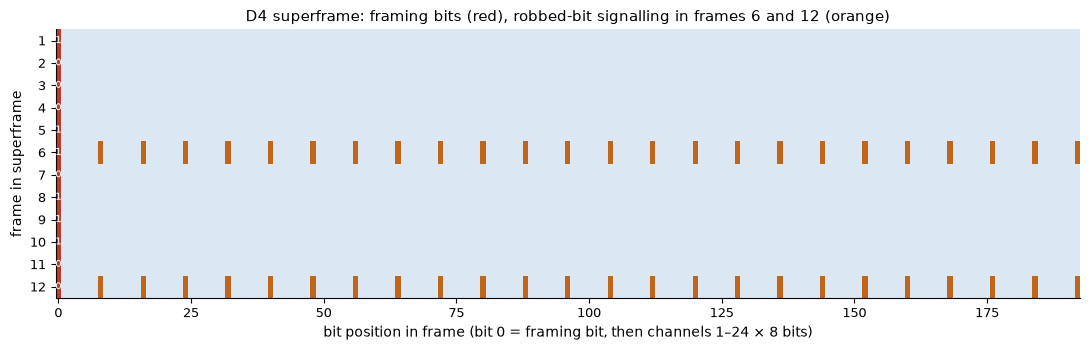

system,voice channels,bits per 125 µs frame,line rate (Mb/s)
T1 / DS1,24,193,1.544
E1,30,256,2.048


In [27]:
fbits = np.array([1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0])                 # D4 framing pattern
sf = np.zeros((12, 193), dtype=int)                                    # 0 = framing, 1 = voice, 2 = robbed bit
sf[:, 1:] = 1
for fr_ in (5, 11):
    sf[fr_, 8::8] = 2                                                  # LSB of each 8-bit channel sample
f, ax = lk.fig((11, 3.6))
from matplotlib.colors import ListedColormap
ax.imshow(sf, aspect="auto", cmap=ListedColormap([lk.RED, "#dbe7f3", lk.ORANGE]), interpolation="nearest")
for r_, b in enumerate(fbits):
    ax.text(0, r_, str(b), ha="center", va="center", color="white", fontsize=7)
ax.set_xlabel("bit position in frame (bit 0 = framing bit, then channels 1–24 × 8 bits)")
ax.set_ylabel("frame in superframe"); ax.set_yticks(range(12), [str(i + 1) for i in range(12)]); ax.grid(False)
ax.set_title("D4 superframe: framing bits (red), robbed-bit signalling in frames 6 and 12 (orange)")
lk.show(f)
lk.table([["T1 / DS1", 24, 193, 193 * 8000 / 1e6], ["E1", 30, 256, 256 * 8000 / 1e6]],
         ["system", "voice channels", "bits per 125 µs frame", "line rate (Mb/s)"], fmt={3: ".3f"})

### Try it yourself 8.1
What fraction of the T1 line rate carries voice payload (24 × 64 kb/s)? Answer as a percentage.

In [29]:
answer_8_1 = None
lk.check("8.1 T1 payload efficiency (%)", answer_8_1, 100 * 24 * 64 / 1544, atol=0.05)

[TODO] 8.1 T1 payload efficiency (%): not attempted yet: replace the None with your answer

## Key takeaways
* Sample above twice the bandwidth *after* an anti-alias filter: aliasing cannot be undone.
* Uniform quantization: 6 dB per bit, 1 dB of SQNR lost per dB of level; dither turns distortion into benign noise.
* Companding (G.711 μ-law/A-law) gives 8-bit PCM the dynamic range of ~13-bit uniform PCM.
* Delta modulation trades slope overload against granular noise; sigma-delta trades speed for resolution with
  noise shaping, $(6L+3)$ dB per octave of OSR.
* T1 = 24 × 64 kb/s + 8 kb/s framing = 1.544 Mb/s; E1 = 32 × 64 kb/s = 2.048 Mb/s.

## Going further (hardware: USRP B200 / GNU Radio)
* The AD9364 in the B200 uses sigma-delta ADCs followed by digital decimation filters: that is why its
  12-bit converters deliver more dynamic range at narrow bandwidths. Capture a tone at 2 MS/s and at 20 MS/s
  and compare the noise floor per Hz.
* Use GNU Radio's audio blocks to record your voice at 8 kHz, then compress it with Section 5's μ-law
  functions and listen to 8-bit uniform versus 8-bit μ-law.

## Exercises
1. **(Warm-up)** Derive $\mathrm{SQNR} = 6.02b + 1.76$ dB for a full-scale sine.
2. **(Core)** Implement the true G.711 segmented μ-law encoder (8 segments × 16 steps) and compare its SQNR
   curve with the smooth law.
3. **(Core)** Implement CVSD (continuously variable slope delta modulation) and compare its SNR with fixed-step
   DM on the Section 6 signal.
4. **(Stretch)** Build a third-order sigma-delta modulator with a stable NTF (e.g. designed with `scipy` from a
   Butterworth high-pass prototype) and measure its peak SQNR and stability limit versus input amplitude.

In [31]:
lk.summary()

[good] Lab 16 finished in 2.2 s. Self-checks: 0 passed, 0 failed, 4 still to do.